# Supplementary Figure S6: classifier smoothing

Compare cell-type predictions across spatial smoothing settings. Recalculate composition and lineage-transition summaries for S6.


## Before you start

Follow the [source installation](../../installation.md), then run these cells in order. The numerical inputs are included with the code. The notebook saves new figures and their calculation tables.

To generate these inputs from fitted models, see the [calculation guide](../../reference/figure_sources/classifier-smoothing.md).


## Imports and configuration

In [1]:
import os
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import load_classifier_smoothing_results
from CytoBridge.results.classifier_smoothing import (
    classifier_smoothing_statistics,
    write_classifier_smoothing_tables,
)

output_dir = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")) / "outputs" / "classifier_smoothing"
output_dir.mkdir(parents=True, exist_ok=True)

## Load processed results

In [2]:
results = load_classifier_smoothing_results()
display(results.metrics.head())
display(results.policy)

,dataset,k,n_heldout,balanced_accuracy,macro_f1,accuracy
0,admouse,1,17210,0.954482,0.953965,0.960604
1,admouse,5,17210,0.461769,0.462742,0.628007
2,admouse,10,17210,0.429242,0.420548,0.604474
3,admouse,20,17210,0.414375,0.396418,0.596572
4,admouse,50,17210,0.399508,0.377927,0.585764


,dataset,accuracy_best_k,formal_analysis_k,rationale
0,zebrafish,1,10,Spatially regularized tissue-domain labels; use the same k in every analysis and figure that uses these labels
1,mosta,1,10,Spatially regularized tissue-domain labels; use the same k in every analysis and figure that uses these labels
2,arista,1,10,Spatially regularized tissue-domain labels; use the same k in every analysis and figure that uses these labels
3,admouse,1,1,Heterogeneous and rare populations are strongly suppressed by larger-k smoothing; retain raw MLP labels
4,chicken_heart,1,1,Developing-heart cell types include spatially restricted populations; retain the validation-selected unsmoothed MLP labels


## Recalculate panel data

Composition s.e.m. is calculated over nine generated frames per `k`; transition s.e.m. is calculated over four fixed-cohort intervals per `k`.

In [3]:
display(results.composition)
display(results.transition)

,k,mean,sem
0,1,0.000000,0.000000
1,5,4.630056,0.700403
2,10,7.649367,1.347172
3,20,10.384740,2.045209
4,50,14.462290,2.699662


,k,mean,sem
0,1,87.477798,4.480284
1,5,88.321492,4.741916
2,10,87.522202,5.231690
3,20,87.655417,5.331310
4,50,88.277087,5.189116


## Render and save the figure

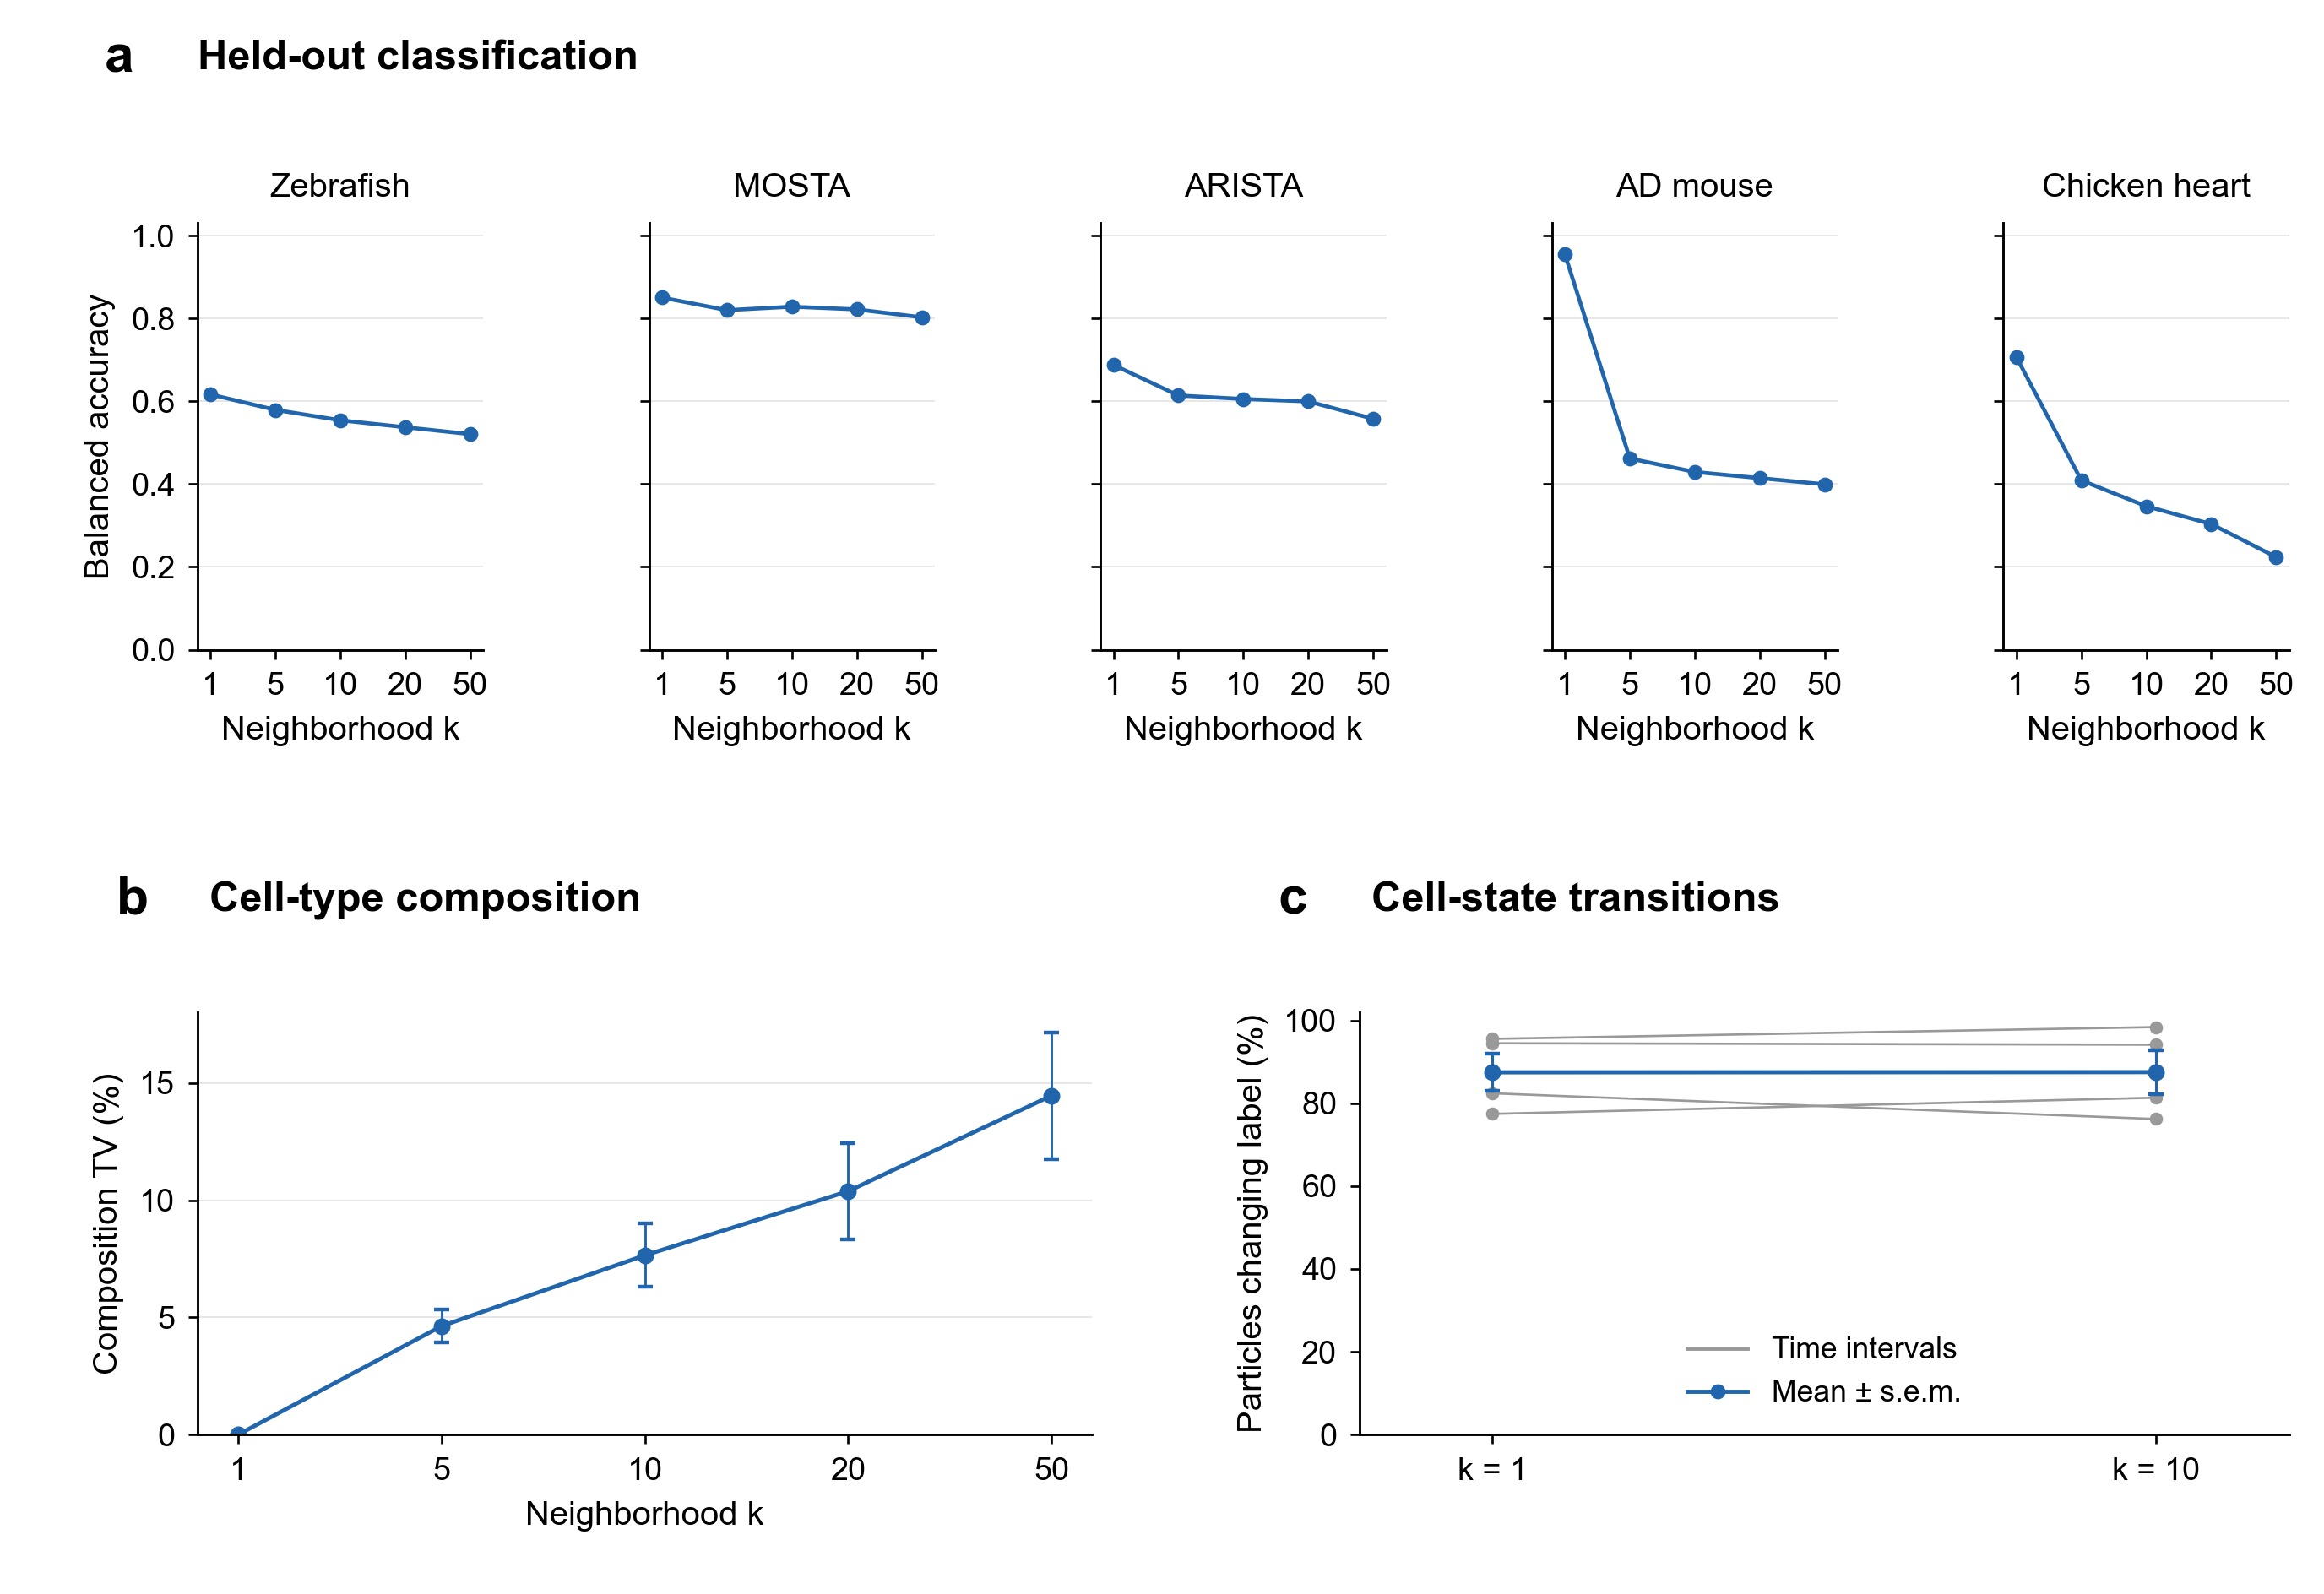

In [4]:
table_paths = write_classifier_smoothing_tables(results, output_dir)
from reproduction.paper_figures import draw_supplementary
pdf_path, png_path = draw_supplementary([6], output_dir)["s6"]
display(Image(filename=str(png_path), width=900))

## Check outputs

In [5]:
{
    "statistics": classifier_smoothing_statistics(results),
    "tables": {name: path.is_file() for name, path in table_paths.items()},
    "pdf": pdf_path.is_file(),
    "png": png_path.is_file(),
}

{'statistics': {'arista_balanced_accuracy_k1': 0.6877649953746441,
  'arista_balanced_accuracy_k10': 0.6054732207227296,
  'chicken_heart_balanced_accuracy_k1': 0.7065001148660296,
  'chicken_heart_balanced_accuracy_k10': 0.3465771733968439,
  'zebrafish_composition_tv_percent_k10': 7.649366770733167,
  'zebrafish_transition_fraction_percent_k1': 87.47779751332149,
  'zebrafish_transition_fraction_percent_k10': 87.52220248667851,
  'zebrafish_transition_percentage_point_delta_k10_vs_k1': 0.04440497335701821},
 'tables': {'metrics': True,
  'policy': True,
  'composition': True,
  'transition': True},
 'pdf': True,
 'png': True}

## Calculate classifier results

The [classifier calculation guide](../../reference/figure_sources/classifier-smoothing.md) describes how to fit the classifiers and compare their predictions. The plotting cells here use the paper's included results.
